In [37]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import seaborn as sns

In [52]:
# Hyperparameters
SEED = 42
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 100
HIDDEN_SIZE = 64
TEST_SIZE = 0.2
DROPOUT_RATE = 0.3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load dataset

In [38]:
features = ["mean_speed_in_end_PTL","mean_speed_in_PTL","num_total_vehs","num_vehs_in_PTL","closed","av_rate"]
experiments = ["LeftCompDaily","LeftCompScenarios","ClosedLeftCompScenarios"]
target = "mean_pass_delay_timestamp"
MinNumPassRange = [1,2,3,4,5,6]

In [39]:
dataset = pd.read_pickle('datasetWP.pkl')
dataset["av_rate"] = dataset["project_name"].apply(lambda x: float(x.split("_")[-1][2:]))
dataset["closed"] = dataset["project_name"].apply(lambda x: int("Closed" in x))
dataset.head()

,mean_speed_in_end_PTL,mean_speed_in_PTL,num_total_vehs,num_vehs_in_PTL,MinNumPass,mean_pass_delay_timestamp,project_name,av_rate,closed
0,25.000000,25.487258,228.0,2.0,1.0,2.350,LeftCompDaily_av0.1,0.1,0
1,25.000000,24.880593,393.0,6.0,1.0,11.250,LeftCompDaily_av0.1,0.1,0
2,25.000000,21.702472,460.0,14.0,1.0,38.145,LeftCompDaily_av0.1,0.1,0
3,21.035965,22.032360,496.0,16.0,1.0,61.970,LeftCompDaily_av0.1,0.1,0
4,13.139630,21.772567,527.0,16.0,2.0,85.825,LeftCompDaily_av0.1,0.1,0


# Explore dataset

<Axes: >

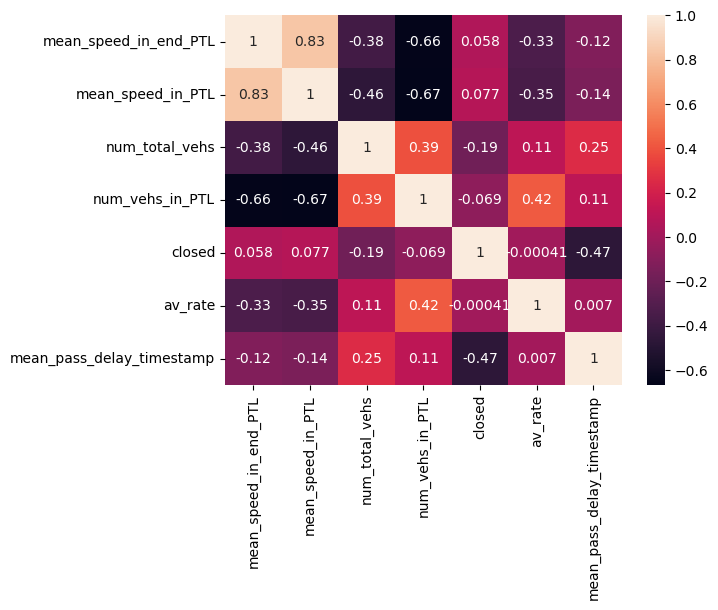

In [40]:
# Create a correlation matrix
corr = dataset[features+[target]].corr()
sns.heatmap(corr, annot=True)

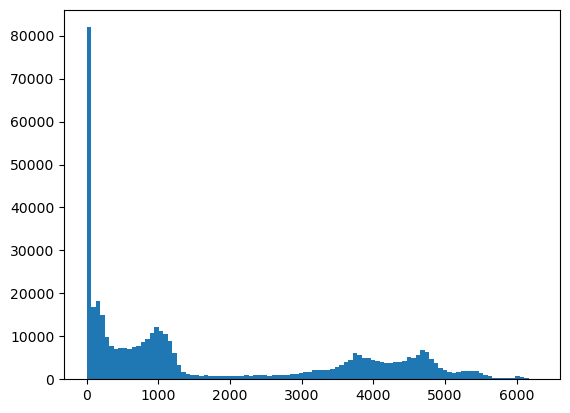

In [41]:
# Plot the distribution of the target variable
plt.hist(dataset[target], bins=100)
plt.show()

# Create dataloaders

In [42]:
class Dataset(torch.utils.data.Dataset):
    def __init__(self, MinNumPass):
        self.X = torch.tensor(dataset[dataset["MinNumPass"]==MinNumPass][features].values, dtype=torch.float32)
        self.y = torch.tensor(dataset[dataset["MinNumPass"]==MinNumPass][target].values, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [46]:
train_dataloaders = {}
test_dataloaders = {}
for MinNumPass in MinNumPassRange:
    dataset_MinNumPass = Dataset(MinNumPass)
    print(MinNumPass, len(dataset_MinNumPass))
    # split dataset
    X_train, X_test, y_train, y_test = train_test_split(dataset_MinNumPass.X, dataset_MinNumPass.y, test_size=TEST_SIZE, random_state=SEED)
    # create dataloaders
    train_dataloaders[MinNumPass] = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    test_dataloaders[MinNumPass] = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

1 288193
2 45512
3 29649
4 30749
5 22407
6 29482


# Create a simple neural network

In [48]:
class DelayPredictor(nn.Module):
    def __init__(self):
        super(DelayPredictor, self).__init__()
        self.fc1 = nn.Linear(len(features), HIDDEN_SIZE)
        self.fc2 = nn.Linear(HIDDEN_SIZE,HIDDEN_SIZE//2)
        self.fc3 = nn.Linear(HIDDEN_SIZE//2,1)
        self.dropout = nn.Dropout(DROPOUT_RATE)
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.fc3(x)
        return x

# Train the model for each MinNumPass

MinNumPass 1:   0%|          | 0/100 [00:00<?, ?it/s]

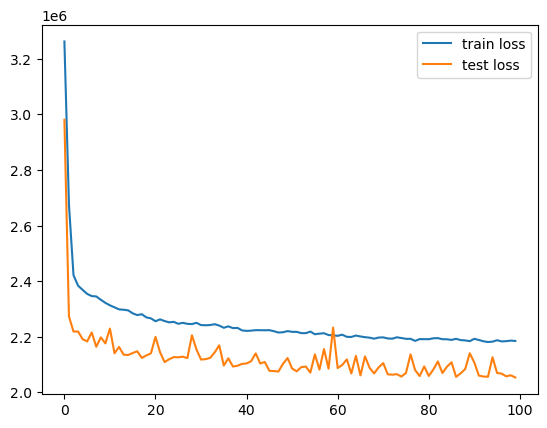

MinNumPass 2:   0%|          | 0/100 [00:00<?, ?it/s]

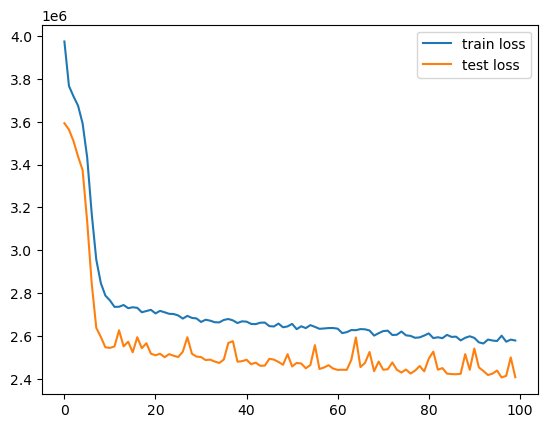

MinNumPass 3:   0%|          | 0/100 [00:00<?, ?it/s]

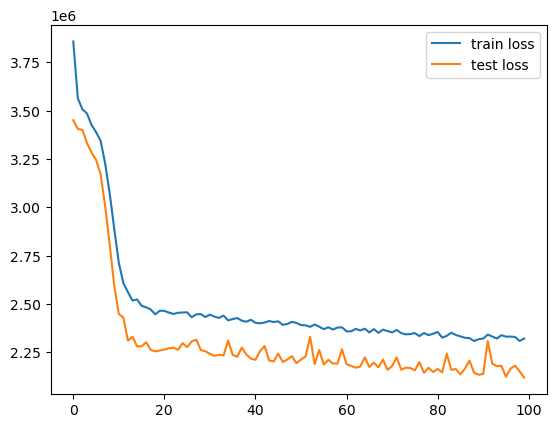

MinNumPass 4:   0%|          | 0/100 [00:00<?, ?it/s]

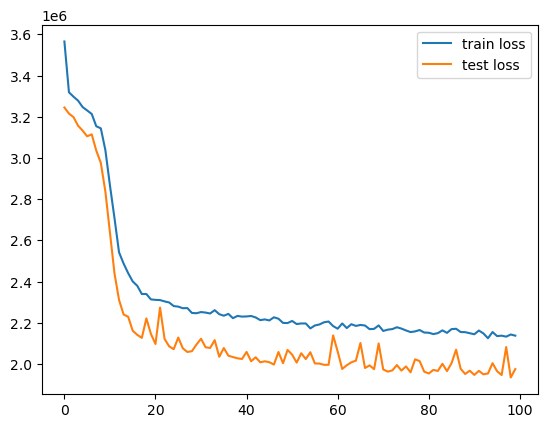

MinNumPass 5:   0%|          | 0/100 [00:00<?, ?it/s]

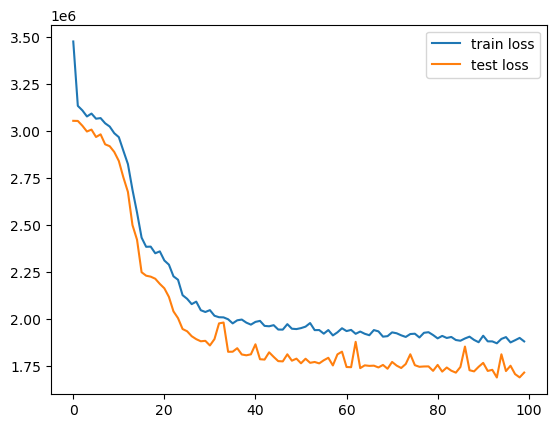

MinNumPass 6:   0%|          | 0/100 [00:00<?, ?it/s]

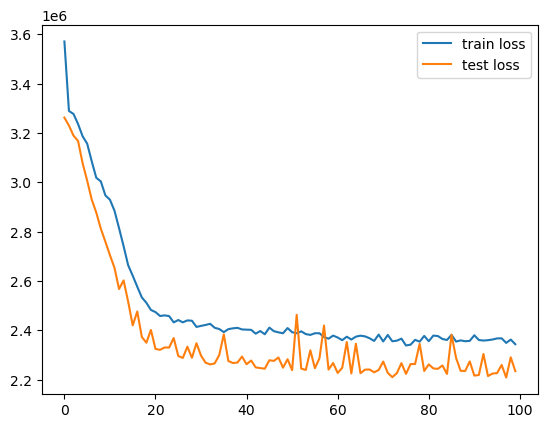

In [60]:
from tqdm.auto import tqdm

for MinNumPass in MinNumPassRange:
    model = DelayPredictor()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_dataloader = train_dataloaders[MinNumPass]
    test_dataloader = test_dataloaders[MinNumPass]
    model.to(device)
    model.train()
    # write the training loop, with training and validation loss into tqdm and a list
    train_losses = []
    test_losses = []
    epochs_progress = tqdm(range(EPOCHS), desc=f"MinNumPass {MinNumPass}")
    for epoch in epochs_progress:
        train_loss = 0
        test_loss = 0

        for X_batch, y_batch in train_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch.unsqueeze(1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_losses.append(train_loss/len(train_dataloader))
        with torch.no_grad():
            model.eval()
            for X_batch, y_batch in test_dataloader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch.unsqueeze(1))
                test_loss += loss.item()
            test_losses.append(test_loss/len(test_dataloader))
            model.train()
        epochs_progress.set_postfix(train_loss=train_losses[-1], test_loss=test_losses[-1])
    plt.plot(train_losses, label="train loss")
    plt.plot(test_losses, label="test loss")
    plt.legend()
    plt.show()

In [ ]:
from tqdm.auto import tqdm
HIDDEN_SIZE = 256
for MinNumPass in MinNumPassRange:
    model = DelayPredictor()
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    train_dataloader = train_dataloaders[MinNumPass]
    test_dataloader = test_dataloaders[MinNumPass]
    model.to(device)
    model.train()
    # write the training loop, with training and validation loss into tqdm and a list
    train_losses = []
    test_losses = []
    epochs_progress = tqdm(range(EPOCHS), desc=f"MinNumPass {MinNumPass}")
    for epoch in epochs_progress:
        train_loss = 0
        test_loss = 0

        for X_batch, y_batch in train_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch.unsqueeze(1))
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_losses.append(train_loss/len(train_dataloader))
        with torch.no_grad():
            model.eval()
            for X_batch, y_batch in test_dataloader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch.unsqueeze(1))
                test_loss += loss.item()
            test_losses.append(test_loss/len(test_dataloader))
            model.train()
        epochs_progress.set_postfix(train_loss=train_losses[-1], test_loss=test_losses[-1])
    plt.plot(train_losses, label="train loss")
    plt.plot(test_losses, label="test loss")
    plt.legend()
    plt.show()

MinNumPass 1:   0%|          | 0/100 [00:00<?, ?it/s]